## Load dataset

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path("../exploration/data/coffee_sales_prepared.parquet")

df = pd.read_parquet(data_path)
df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,day_of_week,day_of_week_num,month,year,is_weekend,season
0,2024-03-01,2024-03-01 10:15:50.520,card,anon-0000-0000-0001,38.7,latte,10,Friday,4,3,2024,False,spring
1,2024-03-01,2024-03-01 12:19:22.539,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
2,2024-03-01,2024-03-01 12:20:18.089,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
3,2024-03-01,2024-03-01 13:46:33.006,card,anon-0000-0000-0003,28.9,americano,13,Friday,4,3,2024,False,spring
4,2024-03-01,2024-03-01 13:48:14.626,card,anon-0000-0000-0004,38.7,latte,13,Friday,4,3,2024,False,spring


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales_by_weekday = (
    df.groupby(["day_of_week_num", "day_of_week"])
      .agg(total_revenue=("money", "sum"))
      .reset_index()
      .sort_values("day_of_week_num")
)

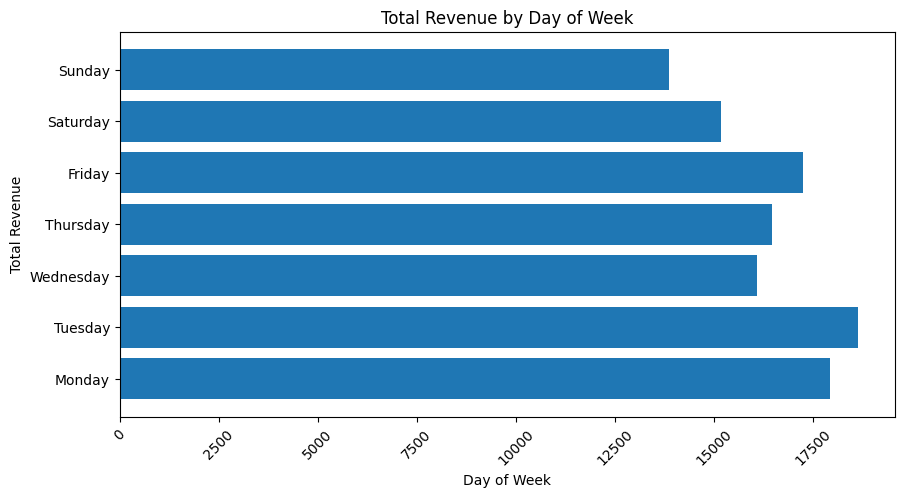

In [7]:
plt.figure(figsize=(10, 5))
plt.barh(sales_by_weekday["day_of_week"], sales_by_weekday["total_revenue"])
plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [8]:
hourly_demand = (
    df.groupby("hour")
      .agg(
          total_transactions=("money", "count"),
          total_revenue=("money", "sum")
      )
      .reset_index()
)

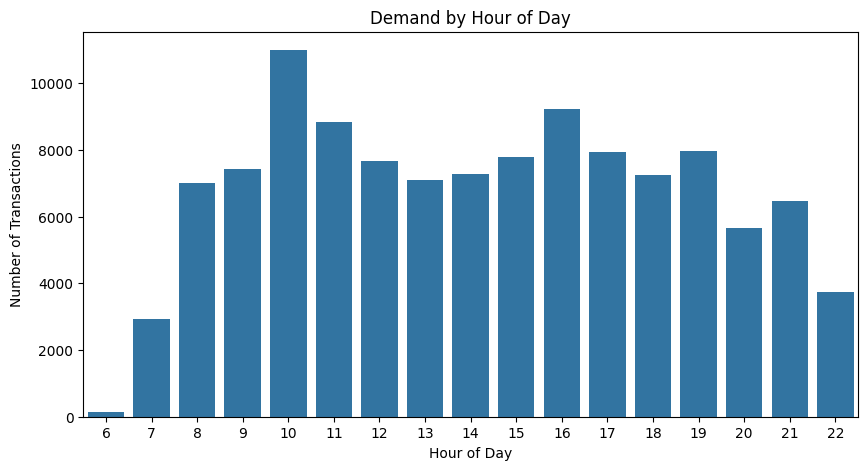

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=hourly_demand,
    x="hour",
    y="total_revenue"
)

plt.title("Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

Como coffe_name e season são variaveis categóricas, o mais apropriado é realizar uma analise por associação. Assim, pode-se observar a distribuição percentual de vandas por tipo de bebida em cada estação do ano. Utilizando um heatmap, um insight interessante é que em todas as estações do ano, as bebidas a base de leite representam a maior participação nas vendas. Isso pode ser importante no cenário em oferecer mix de produtos por estação e possíveis campanhas sazonais.

Insights adicionais possíveis:
- Produto âncora: se bebidas com leite lideram em todas as estações, elas podem ser tratadas como produtos principais do portfólio. O negócio deve evitar ruptura desses itens.
- Campanhas sazonais: se algum café aumenta participação em uma estação específica, ele pode ser usado em campanhas temporárias, combos ou destaque na comunicação da máquina.
- Gestão de estoque: a sazonalidade do mix ajuda a planejar reposição por tipo de bebida, não apenas volume total de vendas.

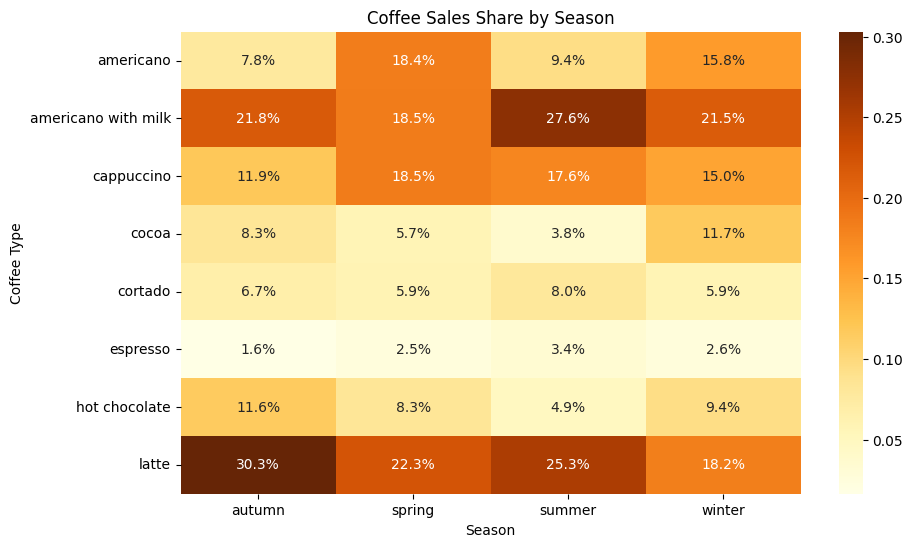

In [12]:
coffee_season = pd.crosstab(
    df["coffee_name"],
    df["season"],
    values=df["money"],
    aggfunc="sum",
    normalize="columns"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(coffee_season, annot=True, fmt=".1%", cmap="YlOrBr")

plt.title("Coffee Sales Share by Season")
plt.xlabel("Season")
plt.ylabel("Coffee Type")
plt.show()

In [13]:
daily_sales = (
    df.groupby("date")
      .agg(
          total_revenue=("money", "sum"),
          total_transactions=("money", "count")
      )
      .reset_index()
      .sort_values("date")
)

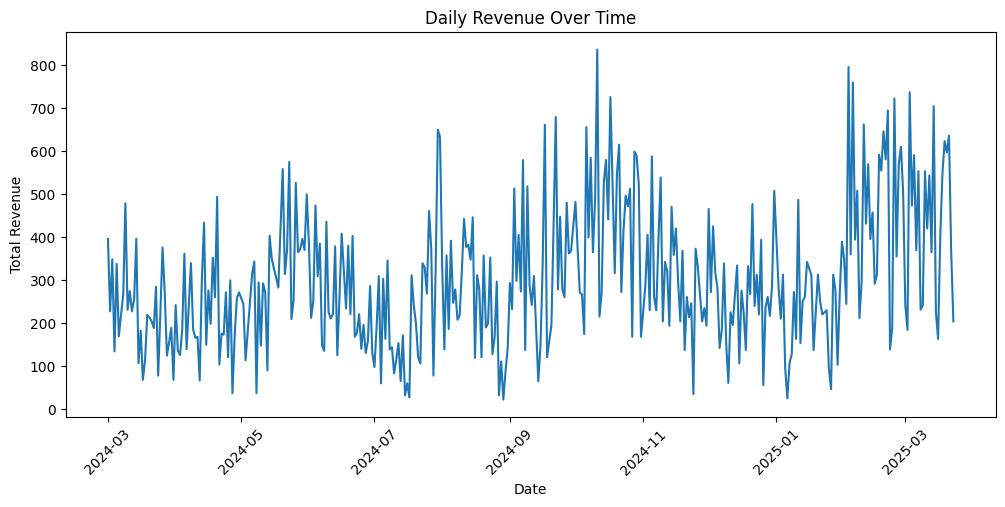

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["total_revenue"])

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

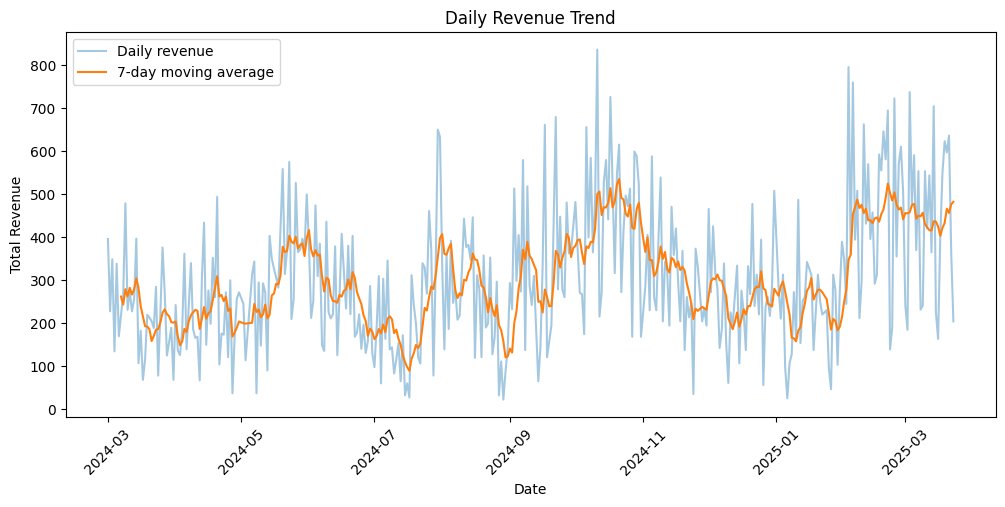

In [15]:
daily_sales["revenue_7d_avg"] = daily_sales["total_revenue"].rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["total_revenue"], alpha=0.4, label="Daily revenue")
plt.plot(daily_sales["date"], daily_sales["revenue_7d_avg"], label="7-day moving average")

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()